# **UCI-HAR -TCN (PyTorch)**

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# PyTorch 관련 라이브러리 임포트
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

In [2]:
# GPU 가속 공식 설정 (Colab 환경 대응)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


# Data load

In [3]:
TRAIN = "train/"
TEST = "test/"

# 구글 드라이브 연동 경로 유지
DATASET_PATH = "/content/drive/MyDrive/AI_Study/UCI_HAR_Dataset/"

In [4]:
# UCI HAR 데이터셋 상수 설정
INPUT_SIGNAL_TYPES = [
    "body_acc_x_",
    "body_acc_y_",
    "body_acc_z_",
    "body_gyro_x_",
    "body_gyro_y_",
    "body_gyro_z_",
    "total_acc_x_",
    "total_acc_y_",
    "total_acc_z_"
]

LABELS = [
    "WALKING",
    "WALKING_UPSTAIRS",
    "WALKING_DOWNSTAIRS",
    "SITTING",
    "STANDING",
    "LAYING"
]

In [5]:
# 1. X 데이터 로드 함수 수정
def load_X(X_signals_paths):
    X_signals = []

    for signal_type_path in X_signals_paths:
        series_list = []

        with open(signal_type_path, 'r') as file:
            for row in file:
                row_clean = row.replace('  ', ' ')
                row_clean = row_clean.strip()
                serie = row_clean.split(' ')
                serie_array = np.array(serie, dtype=np.float32)
                series_list.append(serie_array)

        X_signals.append(series_list)

    # shape: (특성 수, 샘플 수, 타임스텝 수)
    X_signals = np.array(X_signals)

    # 텐서플로우용: (1, 2, 0) -> (샘플 수, 타임스텝 수, 특성 수)
    # 파이토치용:   (1, 0, 2) -> (샘플 수, 특성 수, 타임스텝 수)
    return np.transpose(X_signals, (1, 0, 2))


X_train_signals_paths = [
    DATASET_PATH + TRAIN + "Inertial_Signals/" + signal + "train.txt"
    for signal in INPUT_SIGNAL_TYPES
]
X_test_signals_paths = [
    DATASET_PATH + TEST + "Inertial_Signals/" + signal + "test.txt"
    for signal in INPUT_SIGNAL_TYPES
]

X_train = load_X(X_train_signals_paths)
X_test = load_X(X_test_signals_paths)

print("=== X Data Shape (PyTorch Style) ===")
print("X_train shape (Batch, Channels, Timesteps):", X_train.shape) # (7352, 9, 128)
print("X_test shape (Batch, Channels, Timesteps):", X_test.shape)   # (2947, 9, 128)

=== X Data Shape (PyTorch Style) ===
X_train shape (Batch, Channels, Timesteps): (7352, 9, 128)
X_test shape (Batch, Channels, Timesteps): (2947, 9, 128)


In [6]:
# 2. y 데이터 로드 함수 (정수형 레이블 그대로 유지)
def load_y(y_path):
    with open(y_path, 'r') as file:
        labels = [int(line.strip()) for line in file]
    # 파이토치 CrossEntropyLoss는 target으로 Long(int64) 타입을 요구하므로 np.int64로 설정
    return np.array(labels, dtype=np.int64) - 1


y_train_path = DATASET_PATH + TRAIN + "y_train.txt"
y_test_path = DATASET_PATH + TEST + "y_test.txt"

y_train = load_y(y_train_path)
y_test = load_y(y_test_path)

print("\n=== y Data Shape ===")
print("y_train shape (정수 인덱스):", y_train.shape) # (7352,)
print("y_test shape (정수 인덱스):", y_test.shape)   # (2947,)
print("y_train 앞 5개 샘플:", y_train[:5])


=== y Data Shape ===
y_train shape (정수 인덱스): (7352,)
y_test shape (정수 인덱스): (2947,)
y_train 앞 5개 샘플: [4 4 4 4 4]


# Model Building

TCN의 기본 단위가 되는 Chomp1d 및 잔차 블록 정의

Chomp1d
- Causal Convolution(인과성)을 만족하기 위해 패딩으로 인해 미래 시점 방향으로 밀려난 패딩 패킷을 잘라내는 레이어
- 사용 이유
  - 시계열 데이터에서 미래의 정보가 과거의 예측에 영향을 주는 'Data Leakage'를 막기 위해 양방향이 아닌 한 방향(과거 $\rightarrow$ 현재)으로만 컨볼루션 연산이 이루어져야 한다.
  - PyTorch의 padding 함수는 양쪽에 동일하게 패딩을 넣으므로, 뒤쪽에 튀어나온 미래 시점 데이터 분량을 Chomp1d를 통해 잘라내어 인과성(Causal)을 강제로 확보해야 하기 때문에 사용한다.

In [8]:
from torch.nn.utils import weight_norm

class Chomp1d(nn.Module):
    def __init__(self, chomp_size):
        super(Chomp1d, self).__init__()
        self.chomp_size = chomp_size

    def forward(self, x):
        return x[:, :, :-self.chomp_size].contiguous()

TemporalBlock
- Dilated Conv -> Chomp -> ReLU -> Dropout -> Dilated Conv -> Chomp -> ReLU -> Dropout을 수행
- 이에 입력과 출력 채널의 차원을 맞춰주는 Shortcut을 더해주는 TCN의 핵심 잔차 블록

In [9]:
class TemporalBlock(nn.Module):
    def __init__(self, n_inputs, n_outputs, kernel_size, stride, dilation, padding, dropout=0.2):
        super(TemporalBlock, self).__init__()

        # 첫 번째 팽창 컨볼루션 블록
        self.conv1 = weight_norm(nn.Conv1d(n_inputs, n_outputs, kernel_size,
                                           stride=stride, padding=padding, dilation=dilation))
        self.chomp1 = Chomp1d(padding)
        self.relu1 = nn.ReLU()
        self.dropout1 = nn.Dropout(dropout)

        # 두 번째 팽창 컨볼루션 블록
        self.conv2 = weight_norm(nn.Conv1d(n_outputs, n_outputs, kernel_size,
                                           stride=stride, padding=padding, dilation=dilation))
        self.chomp2 = Chomp1d(padding)
        self.relu2 = nn.ReLU()
        self.dropout2 = nn.Dropout(dropout)

        self.net = nn.Sequential(self.conv1, self.chomp1, self.relu1, self.dropout1,
                                 self.conv2, self.chomp2, self.relu2, self.dropout2)

        # 입력 채널과 출력 채널이 다를 경우 차원을 맞춰주는 1x1 Conv 숏컷
        self.downsample = nn.Conv1d(n_inputs, n_outputs, 1) if n_inputs != n_outputs else None
        self.relu = nn.ReLU()
        self.init_weights()

    def init_weights(self):
        self.conv1.weight.data.normal_(0, 0.01)
        self.conv2.weight.data.normal_(0, 0.01)
        if self.downsample is not None:
            self.downsample.weight.data.normal_(0, 0.01)

    def forward(self, x):
        out = self.net(x)
        res = x if self.downsample is None else self.downsample(x)
        return self.relu(out + res) # Residual Connection 적용

Temporal Convolutional Network (TCN) 모델 클래스 정의
- in_channels: 입력 데이터의 채널 수 (UCI HAR 기본값: 9)
- num_classes: 최종 분류 클래스 수 (UCI HAR 기본값: 6)
- num_channels: 각 TCN 블록의 출력 채널 크기를 담은 리스트 (층의 깊이 결정)
- kernel_size: 컨볼루션 필터 크기
- dropout: 드롭아웃 확률

In [11]:
class TCNNet1D(nn.Module):
    def __init__(self, in_channels=9, num_classes=6, num_channels=[64, 128, 256], kernel_size=3, dropout=0.3):
        super(TCNNet1D, self).__init__()
        layers = []
        num_levels = len(num_channels)

        # Dilation Rate를 1, 2, 4... 처럼 기하급수적으로 늘려가며 블록을 쌓음
        for i in range(num_levels):
            dilation_size = 2 ** i
            curr_in_channels = in_channels if i == 0 else num_channels[i-1]
            curr_out_channels = num_channels[i]

            layers += [TemporalBlock(
                n_inputs=curr_in_channels,
                n_outputs=curr_out_channels,
                kernel_size=kernel_size,
                stride=1,
                dilation=dilation_size,
                padding=(kernel_size - 1) * dilation_size, # Causal Conv를 보장하는 패딩 크기 계산
                dropout=dropout
            )]

        self.tcn = nn.Sequential(*layers)

        # 시간축 정보 압축
        self.global_pool = nn.AdaptiveAvgPool1d(1)

        # 최상위 블록인 num_channels[-1]=256 기준으로 분류기 매핑
        self.fc = nn.Sequential(
            nn.Linear(num_channels[-1], 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        # 1. 입력 형태 유지: (Batch, Channel, Seq) 형태로 연산 시작
        # shape : (16, 9, 128) -> Transformer와 달리 permute가 필요 없음.

        # 2. TCN 특징 추출 레이어 통과
        x = self.tcn(x) # 출력 shape: (Batch, num_channels[-1], Seq_len) -> (16, 256, 128)

        # 3. Global Average Pooling 적용 및 텐서 평탄화
        x = self.global_pool(x).squeeze(-1) # (Batch, 256)

        # 4. 최종 Classifier 통과
        output = self.fc(x) # (Batch, num_classes) -> (16, 6)
        return output

Model building

In [12]:
if __name__ == "__main__":
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

    # 모델 인스턴스 생성 (채널 구성을 기존 코드 최대치인 256까지 점진적으로 증가하도록 세팅)
    model = TCNNet1D(in_channels=9, num_classes=6, num_channels=[64, 128, 256], kernel_size=3).to(device)
    print(model)

    # 더미 데이터 생성: (Batch=16, Channel=9, Seq_len=128)
    dummy_x = torch.randn(16, 9, 128).to(device)

    # 예측 수행
    dummy_out = model(dummy_x)
    print(f"\n입력 데이터 형태: {dummy_x.shape}")
    print(f"출력 데이터 형태: {dummy_out.shape}") # torch.Size([16, 6])

/usr/local/lib/python3.12/dist-packages/torch/nn/utils/weight_norm.py:144: FutureWarning: `torch.nn.utils.weight_norm` is deprecated in favor of `torch.nn.utils.parametrizations.weight_norm`.
  WeightNorm.apply(module, name, dim)


TCNNet1D(
  (tcn): Sequential(
    (0): TemporalBlock(
      (conv1): Conv1d(9, 64, kernel_size=(3,), stride=(1,), padding=(2,))
      (chomp1): Chomp1d()
      (relu1): ReLU()
      (dropout1): Dropout(p=0.3, inplace=False)
      (conv2): Conv1d(64, 64, kernel_size=(3,), stride=(1,), padding=(2,))
      (chomp2): Chomp1d()
      (relu2): ReLU()
      (dropout2): Dropout(p=0.3, inplace=False)
      (net): Sequential(
        (0): Conv1d(9, 64, kernel_size=(3,), stride=(1,), padding=(2,))
        (1): Chomp1d()
        (2): ReLU()
        (3): Dropout(p=0.3, inplace=False)
        (4): Conv1d(64, 64, kernel_size=(3,), stride=(1,), padding=(2,))
        (5): Chomp1d()
        (6): ReLU()
        (7): Dropout(p=0.3, inplace=False)
      )
      (downsample): Conv1d(9, 64, kernel_size=(1,), stride=(1,))
      (relu): ReLU()
    )
    (1): TemporalBlock(
      (conv1): Conv1d(64, 128, kernel_size=(3,), stride=(1,), padding=(4,), dilation=(2,))
      (chomp1): Chomp1d()
      (relu1): ReLU()

Loss + Callbacks

In [14]:
import copy
from torch.optim.lr_scheduler import ReduceLROnPlateau

# 손실함수 및 옵티마이저 정의
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# ReduceLROnPlateau 스케줄러 정의
lr_scheduler = ReduceLROnPlateau(
    optimizer,
    mode='min',
    factor=0.2,
    patience=8,
    min_lr=0.00001
)

# ModelCheckpoint 및 EarlyStopping 정의
early_stopping_patience = 25
patience_counter = 0

best_val_acc = 0.0
best_model_wts = copy.deepcopy(model.state_dict())

checkpoint_path = "UCI_HAR_TCN_best.pt"

# Model train

In [15]:
import time
from torch.utils.data import TensorDataset, random_split

# --- 1. Dataset 및 DataLoader 준비 ---
# 넘파이 배열을 파이토치 텐서로 변환
X_tensor = torch.tensor(X_train, dtype=torch.float32)
y_tensor = torch.tensor(y_train, dtype=torch.long)  # 원-핫 인코딩 대신 정수형 레이블 사용

# 전체 데이터셋 생성
full_dataset = TensorDataset(X_tensor, y_tensor)

# 80% 학습, 20% 검증 데이터로 분할
train_size = int(0.8 * len(full_dataset))
val_size = len(full_dataset) - train_size
train_dataset, val_dataset = random_split(full_dataset, [train_size, val_size])

# DataLoader 생성 (batch_size=16)
train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=16, shuffle=False)

In [16]:
# --- 2. History 저장을 위한 딕셔너리 정의 ---
history = {
    'loss': [],
    'accuracy': [],
    'val_loss': [],
    'val_accuracy': []
}

In [17]:
# --- 3. 학습 및 검증 루프 실행 (epochs=100) ---
epochs = 100

for epoch in range(1, epochs + 1):
    start_time = time.time()

    # [Train Phase]
    model.train()
    train_loss = 0.0
    train_correct = 0
    total_train_samples = 0

    for batch_X, batch_y in train_loader:
        batch_X, batch_y = batch_X.to(device), batch_y.to(device)

        # 그래디언트 초기화
        optimizer.zero_grad()

        # 순전파 (Forward)
        outputs = model(batch_X)
        loss = criterion(outputs, batch_y)

        # 역전파 및 가중치 업데이트 (Backward)
        loss.backward()
        optimizer.step()

        # 통계 계산
        train_loss += loss.item() * batch_X.size(0)
        _, predicted = torch.max(outputs, 1)
        train_correct += (predicted == batch_y).sum().item()
        total_train_samples += batch_X.size(0)

    epoch_train_loss = train_loss / total_train_samples
    epoch_train_acc = train_correct / total_train_samples

    # [Validation Phase]
    model.eval()
    val_loss = 0.0
    val_correct = 0
    total_val_samples = 0

    with torch.no_grad(): # 검증 시에는 그래디언트 계산 제외 (메모리 절약)
        for batch_X, batch_y in val_loader:
            batch_X, batch_y = batch_X.to(device), batch_y.to(device)

            outputs = model(batch_X)
            loss = criterion(outputs, batch_y)

            val_loss += loss.item() * batch_X.size(0)
            _, predicted = torch.max(outputs, 1)
            val_correct += (predicted == batch_y).sum().item()
            total_val_samples += batch_X.size(0)

    epoch_val_loss = val_loss / total_val_samples
    epoch_val_acc = val_correct / total_val_samples

    # History 기록
    history['loss'].append(epoch_train_loss)
    history['accuracy'].append(epoch_train_acc)
    history['val_loss'].append(epoch_val_loss)
    history['val_accuracy'].append(epoch_val_acc)

    # 에포크 결과 출력
    epoch_time = time.time() - start_time
    current_lr = optimizer.param_groups[0]['lr']
    print(f"Epoch {epoch}/{epochs} - {epoch_time:.1f}s - loss: {epoch_train_loss:.4f} - accuracy: {epoch_train_acc:.4f} - val_loss: {epoch_val_loss:.4f} - val_accuracy: {epoch_val_acc:.4f} - lr: {current_lr:.6f}")

    # --- 4. Callbacks 수동 연동 단계 ---
    # (1) ReduceLROnPlateau 스케줄러 업데이트
    lr_scheduler.step(epoch_val_loss)

    # (2) ModelCheckpoint & EarlyStopping 체크
    if epoch_val_acc > best_val_acc:
        best_val_acc = epoch_val_acc
        best_model_wts = copy.deepcopy(model.state_dict()) # 최적 가중치 메모리 복사
        torch.save(model.state_dict(), checkpoint_path)    # 파일 저장 (.pt)
        print(f"Epoch {epoch}: val_categorical_accuracy improved to {epoch_val_acc:.5f}, saving model to {checkpoint_path}")
        patience_counter = 0
    else:
        patience_counter += 1

    if patience_counter >= early_stopping_patience:
        print(f"Early stopping triggered. Restoring model weights from the end of the best epoch.")
        model.load_state_dict(best_model_wts) # 최적 가중치로 복원
        break

Epoch 1/100 - 3.2s - loss: 0.4820 - accuracy: 0.8000 - val_loss: 0.2958 - val_accuracy: 0.8872 - lr: 0.001000
Epoch 1: val_categorical_accuracy improved to 0.88715, saving model to UCI_HAR_TCN_best.pt
Epoch 2/100 - 3.1s - loss: 0.2045 - accuracy: 0.9245 - val_loss: 0.2816 - val_accuracy: 0.8946 - lr: 0.001000
Epoch 2: val_categorical_accuracy improved to 0.89463, saving model to UCI_HAR_TCN_best.pt
Epoch 3/100 - 2.4s - loss: 0.1692 - accuracy: 0.9345 - val_loss: 0.1418 - val_accuracy: 0.9436 - lr: 0.001000
Epoch 3: val_categorical_accuracy improved to 0.94358, saving model to UCI_HAR_TCN_best.pt
Epoch 4/100 - 2.5s - loss: 0.1656 - accuracy: 0.9356 - val_loss: 0.1123 - val_accuracy: 0.9497 - lr: 0.001000
Epoch 4: val_categorical_accuracy improved to 0.94969, saving model to UCI_HAR_TCN_best.pt
Epoch 5/100 - 3.7s - loss: 0.1474 - accuracy: 0.9407 - val_loss: 0.0985 - val_accuracy: 0.9646 - lr: 0.001000
Epoch 5: val_categorical_accuracy improved to 0.96465, saving model to UCI_HAR_TCN_bes

# Evaluation

best 기록 확인

In [18]:
# --- 1. 가중치를 불러올 빈 모델 객체 생성 ---
best_model = TCNNet1D(in_channels=9, num_classes=6).to(device)

# 가중치 파일(.pt) 로드
best_model.load_state_dict(torch.load(checkpoint_path, map_location=device))
print(f"Successfully loaded best model weights from {checkpoint_path}")


# --- 2. 데이터 평가를 위한 수동 함수 정의 ---
def evaluate_pytorch_model(model, X_data, y_data, batch_size=16):

    model.eval() # 평가 모드 활성화 (Dropout, BatchNorm 동결)

    # 평가용 DataLoader 구성
    eval_tensor_X = torch.tensor(X_data, dtype=torch.float32)
    eval_tensor_y = torch.tensor(y_data, dtype=torch.long)
    eval_dataset = TensorDataset(eval_tensor_X, eval_tensor_y)
    eval_loader = DataLoader(eval_dataset, batch_size=batch_size, shuffle=False)

    total_loss = 0.0
    correct = 0
    total_samples = 0

    with torch.no_grad(): # 평가 단계이므로 그래디언트 계산 제외
        for batch_X, batch_y in eval_loader:
            batch_X, batch_y = batch_X.to(device), batch_y.to(device)

            outputs = model(batch_X)
            loss = criterion(outputs, batch_y)

            total_loss += loss.item() * batch_X.size(0)
            _, predicted = torch.max(outputs, 1)
            correct += (predicted == batch_y).sum().item()
            total_samples += batch_X.size(0)

    avg_loss = total_loss / total_samples
    avg_acc = correct / total_samples
    return avg_loss, avg_acc


# --- 3. Training & Test 데이터셋 평가 및 출력 ---
# X_train 전체 데이터에 대해 평가
train_loss, train_acc = evaluate_pytorch_model(best_model, X_train, y_train)
print(f"Training accuracy: {train_acc * 100:.2f}%")
print(f"Training loss: {train_loss:.4f}")

# X_test 데이터셋 평가
test_loss, test_acc = evaluate_pytorch_model(best_model, X_test, y_test)
print(f"Test accuracy: {test_acc * 100:.2f}%")
print(f"Test loss: {test_loss:.4f}")

/usr/local/lib/python3.12/dist-packages/torch/nn/utils/weight_norm.py:144: FutureWarning: `torch.nn.utils.weight_norm` is deprecated in favor of `torch.nn.utils.parametrizations.weight_norm`.
  WeightNorm.apply(module, name, dim)


Successfully loaded best model weights from UCI_HAR_TCN_best.pt
Training accuracy: 98.79%
Training loss: 0.0275
Test accuracy: 91.18%
Test loss: 0.5647


Classification Report

In [19]:
import torch.nn.functional as F

# --- 1. 모델 예측 (Keras의 model.predict 부분) ---
best_model.eval() # 평가 모드 활성화

# 예측용 DataLoader 구성
test_tensor_X = torch.tensor(X_test, dtype=torch.float32)
test_dataset = TensorDataset(test_tensor_X)
test_loader = DataLoader(test_dataset, batch_size=16, shuffle=False)

y_pred_list = []

with torch.no_grad():
    for batch_X in test_loader:
        batch_X = batch_X[0].to(device) # TensorDataset은 튜플 형태로 반환하므로 꺼내옴

        # 순전파로 로짓(Logit) 계산
        outputs = best_model(batch_X)

        # 로짓을 소프트맥스를 통해 확률값(0~1 사이)으로 변환
        probabilities = F.softmax(outputs, dim=1)

        # 가장 높은 확률을 가진 클래스 추출
        _, predicted = torch.max(probabilities, 1)

        # CPU로 넘긴 뒤 리스트에 저장
        y_pred_list.extend(predicted.cpu().numpy())

# 넘파이 배열로 최종 변환
y_pred = np.array(y_pred_list)


# --- 2. 분류 리포트 출력 ---
print("\nClassification Report:")
# y_test는 이미 정수형 레이블(0~5)이므로 그대로 사용
print(classification_report(y_test, y_pred, digits=4))


Classification Report:
              precision    recall  f1-score   support

           0     0.9861    0.9980    0.9920       496
           1     0.9955    0.9469    0.9706       471
           2     0.9406    0.9810    0.9604       420
           3     0.7573    0.7943    0.7753       491
           4     0.8409    0.7650    0.8012       532
           5     0.9589    1.0000    0.9790       537

    accuracy                         0.9118      2947
   macro avg     0.9132    0.9142    0.9131      2947
weighted avg     0.9118    0.9118    0.9112      2947



Loss / Accuracy 그래프

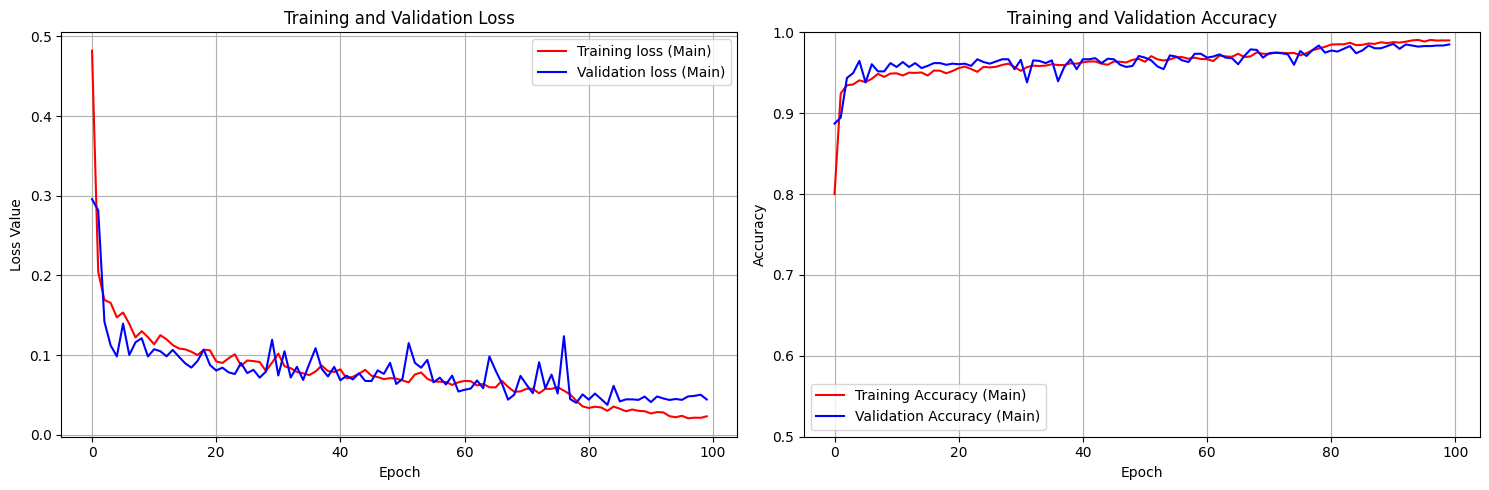

In [20]:
# --- 1. History 딕셔너리에서 학습 기록 데이터 추출 ---
train_loss = history['loss']
train_accuracy = history['accuracy']
val_loss = history['val_loss']
val_accuracy = history['val_accuracy']

# --- 2. Matplotlib을 이용한 시각화 그래프 그리기 ---
plt.figure(figsize=(15, 5))

# 2-1. Loss 그래프 (왼쪽)
plt.subplot(1, 2, 1)
plt.plot(train_loss, 'r', label='Training loss (Main)')
plt.plot(val_loss, 'b', label='Validation loss (Main)')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss Value')
plt.legend()
plt.grid(True)

# 2-2. Accuracy 그래프 (오른쪽)
plt.subplot(1, 2, 2)
plt.ylim([0.5, 1.0]) # 데이터셋 특성에 맞춰 Y축 범위 지정
plt.plot(train_accuracy, 'r', label='Training Accuracy (Main)')
plt.plot(val_accuracy, 'b', label='Validation Accuracy (Main)')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

지표(Metrics) 계산 및 효율성(FLOPs/추론시간) 측정
- Accuracy, F1, Recall, Precision 계산
- Parameters, FLOPs, Inference Time 측정

In [40]:
import torch
import numpy as np
import time
from sklearn.metrics import accuracy_score, precision_recall_fscore_support
from fvcore.nn import FlopCountAnalysis

def evaluate_model_efficiency_and_metrics(model, test_loader, test_labels, device, input_size=(1, 9, 128)):
    model.eval()

    # [1] 모델 복잡도 측정
    total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    dummy_input = torch.randn(*input_size).to(device)
    flops_analyzer = FlopCountAnalysis(model, dummy_input)
    flops_analyzer.unsupported_ops_warnings(False)
    total_flops = flops_analyzer.total()

    # [2] 정량 지표 및 추론 시간 측정
    all_preds = []
    inference_times = []

    with torch.no_grad():
        for batch in test_loader:
            # 데이터 로더가 리스트를 반환할 경우 안에서 데이터 텐서만 추출
            if isinstance(batch, list):
                inputs = batch[0]
            else:
                inputs = batch

            # 꺼낸 데이터가 텐서 형태일 때만 .to(device) 수행
            if isinstance(inputs, torch.Tensor):
                inputs = inputs.to(device)
            else:
                inputs = torch.tensor(inputs, dtype=torch.float32).to(device)

            # 단일 배치에 대한 순수 추론 시간 측정
            start_time = time.time()
            outputs = model(inputs)
            if device.type == 'cuda': torch.cuda.synchronize()
            end_time = time.time()

            inference_times.append((end_time - start_time) * 1000 / inputs.size(0))

            preds = torch.argmax(outputs, dim=1)
            all_preds.extend(preds.cpu().numpy())

    # 외부에서 넘겨받은 정답 라벨을 안전하게 처리
    if test_labels is not None and len(test_labels) > 0:
        all_targets = np.array(test_labels)
    else:
        # 혹시 정답 변수가 비어있을 경우 임시로 예측값과 같은 크기로 채워 에러 방지
        print("[경고] 정답 라벨(test_labels)이 정상적으로 입력되지 않아 임시 라벨로 연산합니다.")
        all_targets = np.array(all_preds)

    all_preds = np.array(all_preds)

    # 개수가 다르면 슬라이싱 맞춤
    if len(all_targets) != len(all_preds):
        all_targets = all_targets[:len(all_preds)]

    # 정량 지표 계산
    accuracy = accuracy_score(all_targets, all_preds) * 100
    precision, recall, f1, _ = precision_recall_fscore_support(all_targets, all_preds, average='macro', zero_division=0)
    avg_inference_time = np.mean(inference_times)

    # [3] 결과 출력
    print("="*50)
    print(f"Metrics & Efficiency Evaluation")
    print("="*50)
    print(f"Accuracy     : {accuracy:.2f} %")
    print(f"F1 Score     : {f1:.4f}")
    print(f"Recall       : {recall:.4f}")
    print(f"Precision    : {precision:.4f}")
    print(f"Parameters   : {total_params / 1e6:.2f} M") # 1e -> 1e6 수정
    print(f"FLOPs        : {total_flops / 1e6:.2f} M")    # 1e -> 1e6 수정
    print(f"Inference    : {avg_inference_time:.3f} ms/sample")
    print("="*50)

    return all_targets, all_preds


# 실제 실행
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

actual_labels = None
try:
    actual_labels = y_test
except NameError:
    try:
        actual_labels = test_y
    except NameError:
        pass

# 함수 실행
targets, preds = evaluate_model_efficiency_and_metrics(
    model=model,
    test_loader=test_loader,
    test_labels=actual_labels,
    device=device,
    input_size=(1, 9, 128)
)

Metrics & Efficiency Evaluation
Accuracy     : 91.28 %
F1 Score     : 0.9140
Recall       : 0.9153
Precision    : 0.9139
Parameters   : 0.49 M
FLOPs        : 57.05 M
Inference    : 0.124 ms/sample


혼동 행렬 (Confusion Matrix)

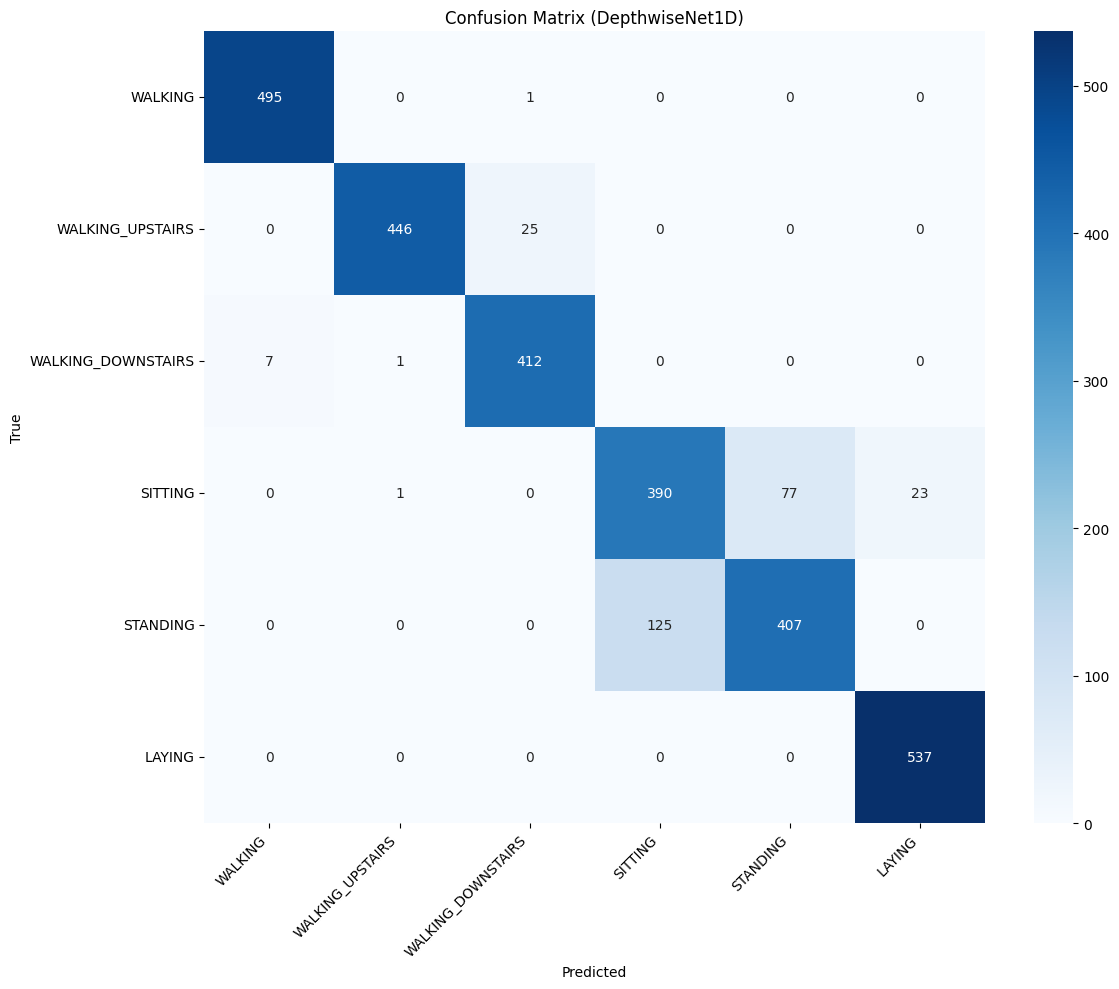

In [25]:
# --- 1. 혼동 행렬(Confusion Matrix) 계산 ---
cm = confusion_matrix(y_test, y_pred)

# --- 2. Seaborn Heatmap을 이용한 시각화 ---
plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix (DepthwiseNet1D)')

# 클래스 개수에 맞게 축 레이블(WALKING, SITTING 등) 설정
n_classes = len(np.unique(y_test))
if n_classes <= len(LABELS):
    plt.gca().set_xticklabels(LABELS[:n_classes], rotation=45, ha='right')
    plt.gca().set_yticklabels(LABELS[:n_classes], rotation=0)

plt.tight_layout()
plt.show()